# AI-Based Household Energy Consumption Prediction

## Names and student numbers:
- Osama Alobaid - X00230146
- Almujtaba Mohamed - X00230145
- Hady Yousef - X00219585

## 1. Project Overview

The First Iteration will focus on:
-   Data Loading - This is done by importing and reading the data so the program can be able to read them.
-   Data Cleaning - This process is done by removing errors, correcting mistakes, filling missing values, and fixing broken data.
-   Data Preprocessing - The data is transformed into a format the program can learn and understand from. For example, converting dates  into a numbers.
-   Exploratory data analysis (EDA) - This process is basically us taking a good look over the data to understand what it contains.
-   Finding Initial Insights -  This part is drawing conclusions from data exploration.

## 2. Dataset Information

Datasets: Household Power Consumption Dataset  
Sources:
- Kaggle
- UCI
- UCI

Each of our rows displays one minute of household electricity consumption.


Our Key Features:
- Global_active_power
- Global_reactive_power
- Voltage
- Global_intensity
- Sub_metering_1
- Sub_metering_2
- Sub_metering_3

Our target variable is Global_active_power.

This is a regression problem.

### 3. Import Required Libraries



We import essential Python libraries for working with data, visualisation, and machine learning model development. This supports repeatability and establishes our technical environment for the project.

In [117]:
import numpy as np
import joblib
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import ShuffleSplit


## 4. Load and Prepare Datasets

### Load and prepare dataset 

Firstly , this section loads the first dataset in a pandas dataframe. The data set has household electricity consumption measurements that are recorded over time. Secondly, the structure of the data is inspected and unnecessary columns are removed. Thirdly, The first few rows are displayed and data shape is printed. Finally, converting data type of certain columns to numeric and dealing with missing values.

In [118]:
filename1 = 'hy_kaggle_household_power_consumption.csv'# Load the dataset file as filename1
data1 = pd.read_csv(filename1)# Read the CSV file into a pandas DataFrame
data1 = data1.drop(columns=['index'])#removing unecessary index column
print("Data shape:", data1.shape)#print data shape
data1.head()#Display first 5 rows

Data shape: (260640, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,01/01/2007,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,01/01/2007,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,01/01/2007,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,01/01/2007,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,01/01/2007,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0


In [119]:
cols1=[#List of containg name columns 
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

data1[cols1]= data1[cols1].apply(pd.to_numeric, errors="coerce")# Convert selected columns to numeric values and converting values that cant be converted to numeric to nan

In [120]:
#Replace any missing value NAN to the median of the column
data1['Global_active_power'].fillna(data1['Global_active_power'].median(), inplace=True) 
data1['Global_reactive_power'].fillna(data1['Global_reactive_power'].median(), inplace=True)
data1['Voltage'].fillna(data1['Voltage'].median(), inplace=True)
data1['Global_intensity'].fillna(data1['Global_intensity'].median(), inplace=True)
data1['Sub_metering_1'].fillna(data1['Sub_metering_1'].median(), inplace=True)
data1['Sub_metering_2'].fillna(data1['Sub_metering_2'].median(), inplace=True)
data1['Sub_metering_3'].fillna(data1['Sub_metering_3'].median(), inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_3244\1567363176.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data1['Global_active_power'].fillna(data1['Global_active_power'].median(), inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_3244\1567363176.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame 

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
260635    18.0
260636    17.0
260637    18.0
260638    18.0
260639    17.0
Name: Sub_metering_3, Length: 260640, dtype: float64

In [121]:
filename2 = 'MJ_household_power_consumption.csv'# Load the dataset file as filename2
data2 = pd.read_csv(filename2, na_values='?', low_memory=False)# Read the CSV file into a pandas DataFrame, treat ? as nan and read the file in one pass
print("Data shape:", data2.shape)#print data shape
data2.head()#Display first 5 rows

Data shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [122]:
cols2=[#List of containg name columns
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

data2[cols2]= data2[cols2].apply(pd.to_numeric, errors="coerce")# Convert selected columns to numeric values and converting values that cant be converted to numeric to nan

In [123]:
#Replace any missing value NAN to the median of the column
data2['Global_active_power'].fillna(data2['Global_active_power'].median(), inplace=True)
data2['Global_reactive_power'].fillna(data2['Global_reactive_power'].median(), inplace=True)
data2['Voltage'].fillna(data2['Voltage'].median(), inplace=True)
data2['Global_intensity'].fillna(data2['Global_intensity'].median(), inplace=True)
data2['Sub_metering_1'].fillna(data2['Sub_metering_1'].median(), inplace=True)
data2['Sub_metering_2'].fillna(data2['Sub_metering_2'].median(), inplace=True)
data2['Sub_metering_3'].fillna(data2['Sub_metering_3'].median(), inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_3244\725224325.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data2['Global_active_power'].fillna(data2['Global_active_power'].median(), inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_3244\725224325.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or

0          17.0
1          16.0
2          17.0
3          17.0
4          17.0
           ... 
2075254     0.0
2075255     0.0
2075256     0.0
2075257     0.0
2075258     0.0
Name: Sub_metering_3, Length: 2075259, dtype: float64

In [124]:
filename3 = 'oa_archive_household_power_consumption.csv'# Load the dataset file as filename3
data3 = pd.read_csv(filename3)# Read the CSV file into a pandas DataFrame
print("Data shape:", data3.shape)#print data shape
data3.head()#display first 5 rows

Data shape: (1048575, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [125]:
cols3=[# list containg name of columns
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

data3[cols3]= data3[cols3].apply(pd.to_numeric, errors="coerce")# Convert selected columns to numeric values and converting values that cant be converted to numeric to nan

In [126]:
#Replace any missing value NAN to the median of the column
data3['Global_active_power'].fillna(data3['Global_active_power'].median(), inplace=True)
data3['Global_reactive_power'].fillna(data3['Global_reactive_power'].median(), inplace=True)
data3['Voltage'].fillna(data3['Voltage'].median(), inplace=True)
data3['Global_intensity'].fillna(data3['Global_intensity'].median(), inplace=True)
data3['Sub_metering_1'].fillna(data3['Sub_metering_1'].median(), inplace=True)
data3['Sub_metering_2'].fillna(data3['Sub_metering_2'].median(), inplace=True)
data3['Sub_metering_3'].fillna(data3['Sub_metering_3'].median(), inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_3244\2929620106.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data3['Global_active_power'].fillna(data3['Global_active_power'].median(), inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_3244\2929620106.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame 

0          17.0
1          16.0
2          17.0
3          17.0
4          17.0
           ... 
1048570     0.0
1048571     0.0
1048572     0.0
1048573     0.0
1048574     0.0
Name: Sub_metering_3, Length: 1048575, dtype: float64

## 5. Starting Data Inspection

In this section, I used .info(), to figure out the data types and the structure of the data. I also used .describe() which displays a summary of all statistics. As well as that, I used isna().sum() to identify missing values.

This process is usually done before preprocessing and is important for identifying the quality of the data for each dataset.

In [127]:
#Display information about each data set column names,data types and number of null values
data1.info()
data2.info()
data3.info()

<class 'pandas.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   260640 non-null  str    
 1   Time                   260640 non-null  str    
 2   Global_active_power    256869 non-null  float64
 3   Global_reactive_power  256869 non-null  float64
 4   Voltage                256869 non-null  float64
 5   Global_intensity       256869 non-null  float64
 6   Sub_metering_1         256869 non-null  float64
 7   Sub_metering_2         256869 non-null  float64
 8   Sub_metering_3         256869 non-null  float64
dtypes: float64(7), str(2)
memory usage: 17.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power

In [128]:
data1.describe()#displays a summary of statistics of numeric columns 

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,256869.000000,256869.000000,256869.000000,256869.000000,256869.000000,256869.000000,256869.000000
mean,1.164937,0.123729,239.208981,4.974755,1.332481,1.670610,5.831825
std,1.181832,0.111872,3.592793,4.999493,6.704970,6.631361,8.186709
min,0.082000,0.000000,223.490000,0.400000,0.000000,0.000000,0.000000
25%,0.296000,0.000000,236.650000,1.400000,0.000000,0.000000,0.000000
50%,0.564000,0.104000,239.610000,2.600000,0.000000,0.000000,0.000000
75%,1.606000,0.194000,241.810000,6.800000,0.000000,1.000000,17.000000
max,10.670000,1.148000,250.890000,46.400000,78.000000,78.000000,20.000000


In [129]:
data2.describe()#displays a summary of statistics of numeric columns 

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [130]:
data3.describe()#displays a summary of statistics of numeric columns 

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06
mean,1.108202e+00,1.182732e-01,2.399598e+02,4.718123e+00,1.177451e+00,1.475177e+00,5.933837e+00
std,1.129546e+00,1.095062e-01,3.284504e+00,4.763588e+00,6.321183e+00,6.352703e+00,8.210398e+00
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.880000e-01,0.000000e+00,2.379700e+02,1.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.544000e+00,1.860000e-01,2.421400e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01,8.000000e+01,7.800000e+01,3.100000e+01


In [131]:
# Missing values summary
data1.isna().sum()

Date                        0
Time                        0
Global_active_power      3771
Global_reactive_power    3771
Voltage                  3771
Global_intensity         3771
Sub_metering_1           3771
Sub_metering_2           3771
Sub_metering_3           3771
dtype: int64

In [132]:
# Missing values summary
data2.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [133]:
# Missing values summary
data3.isna().sum()

Date                        0
Time                        0
Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3           4069
dtype: int64

## 6. Data Cleaning & Pre processing

This part focuses on detecting duplicates and removing them and diplaying the final shape of data before merging our datasets

In [134]:
duplicates = data1.duplicated().sum()# check for duplicate row in set1 and count duplicate rows
print("Duplicate rows:", duplicates)#print the number of duplicate rows

print("Data shape before dropping duplicates:", data1.shape)#Print data shape


if duplicates > 0:#check if duplicates exist
    data1 = data1.drop_duplicates()

print(f"\nData shape after dropping duplicates:", data1.shape)#Print data shape


Duplicate rows: 0
Data shape before dropping duplicates: (260640, 9)

Data shape after dropping duplicates: (260640, 9)


In [135]:
duplicates = data2.duplicated().sum()# check for duplicate row in set2 and count duplicate rows
print("Duplicate rows:", duplicates)#print the number of duplicate rows

print("Data shape before dropping duplicates:", data2.shape)#Print data shape


if duplicates > 0:#check if duplicates exist
    data2 = data2.drop_duplicates()

print(f"\nData shape after dropping duplicates:", data2.shape)#Print data shape


Duplicate rows: 0
Data shape before dropping duplicates: (2075259, 9)

Data shape after dropping duplicates: (2075259, 9)


In [136]:
duplicates = data3.duplicated().sum()# check for duplicate row in set3 and count duplicate rows
print("Duplicate rows:", duplicates)#print the number of duplicate rows

print("Data shape before dropping duplicates:", data3.shape)#Print data shape

if duplicates > 0:#check if duplicates exist
    data3 = data3.drop_duplicates()

print(f"\nData shape after dropping duplicates:", data3.shape)#Print data shape


Duplicate rows: 0
Data shape before dropping duplicates: (1048575, 9)

Data shape after dropping duplicates: (1048575, 9)


## Outliers

### Outlier detection and removal
In this step Numerical and categorical columns are identified , boxplots are used to visually inspect outliers and The Interquartile Range (IQR) method is used to detect and remove outliers.
The process of dealing with outliers is a little bit more complicated. We need to first identify what would classify as an outlier by using Interquartile Range (IQR) method.By creating range for data by subtracting the first quartile from the third quartile we have our accept range and every thing not within is and outlier we need to remove.

Categorical columns: ['Date', 'Time']
Numerical columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Shape before outlier removal: (260640, 9)


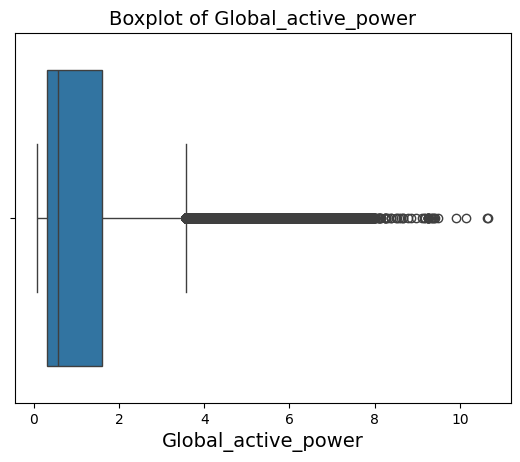

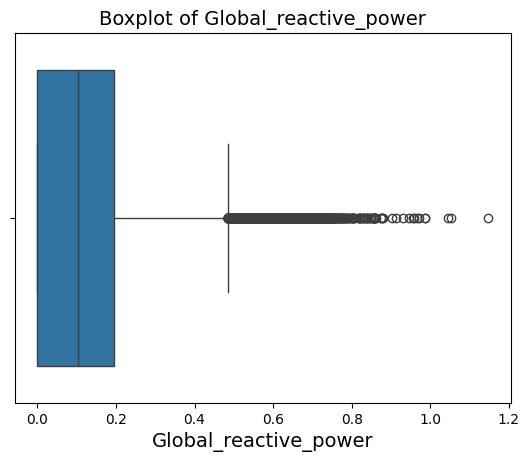

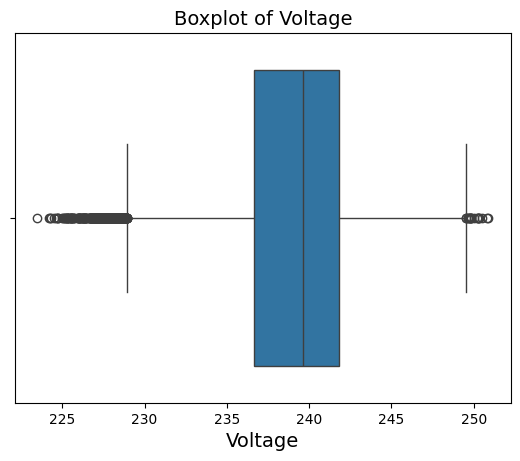

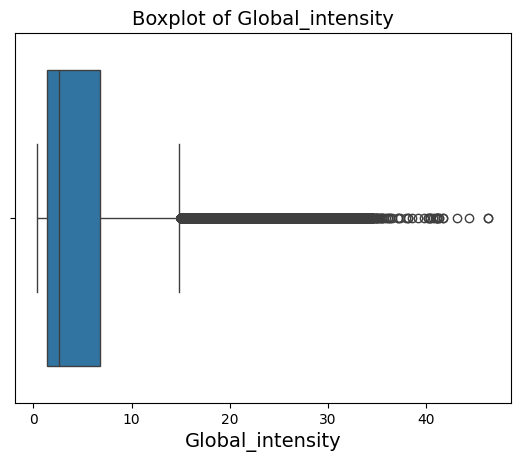

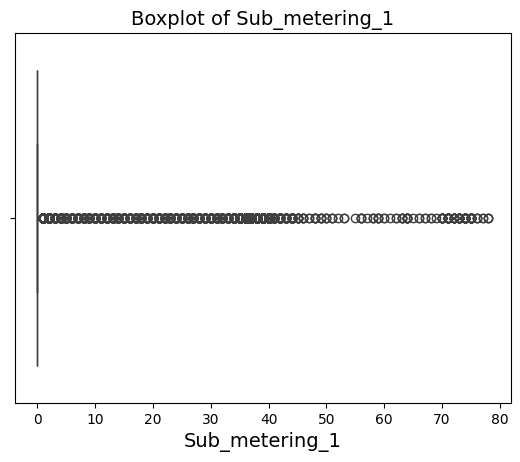

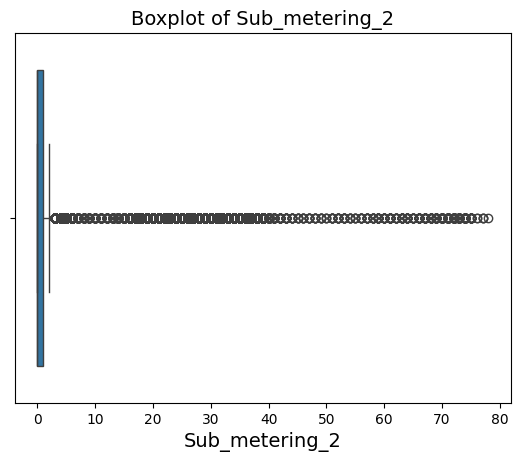

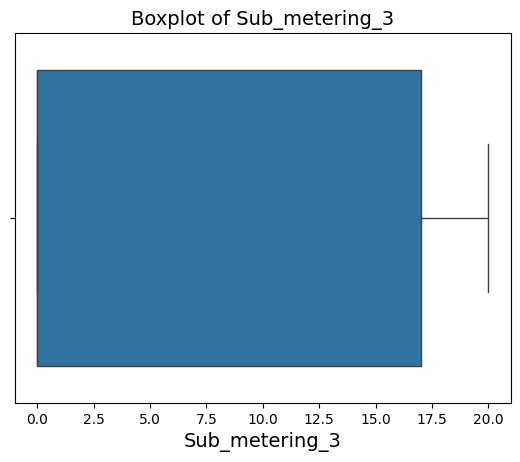

Shape after outlier removal: (217149, 9)


In [137]:
cat_col1 = [col for col in data1.columns if data1[col].dtype == 'string']#categorical columns string type
num_col1= [col for col in data1.columns if data1[col].dtype == 'float' ]#numerical columns float type
# Print column types
print('Categorical columns:', cat_col1)
print('Numerical columns:', num_col1)


print("Shape before outlier removal:", data1.shape)# printdataset size before removing outliers


for col in num_col1:# Plot boxplots to visually detect outliers
    sns.boxplot(x=data1[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


for col in num_col1:# Remove outliers using the IQR method
    Q1 = data1[col].quantile(0.25)   # Calculate quartiles
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1   # Calculate IQR
    lower = Q1 - 1.5 * IQR# lower limits
    upper = Q3 + 1.5 * IQR# upper limits
    data1 = data1[(data1[col] >= lower) & (data1[col] <= upper)] # Filter the dataset to remove outliers

print("Shape after outlier removal:", data1.shape)# print dataset size after removing outliers



Categorical columns: ['Date', 'Time']
Numerical columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Shape before outlier removal: (2075259, 9)


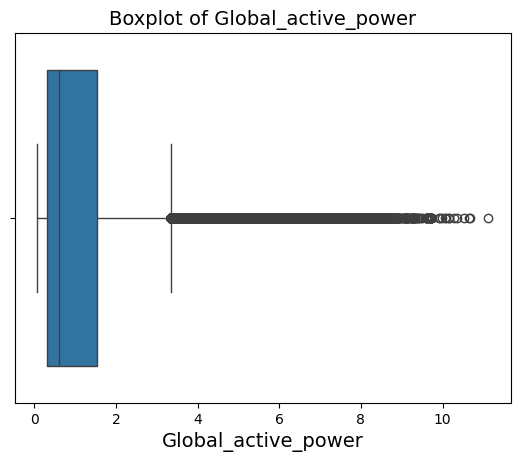

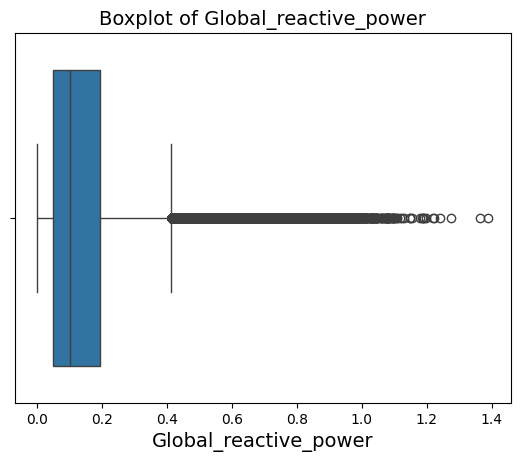

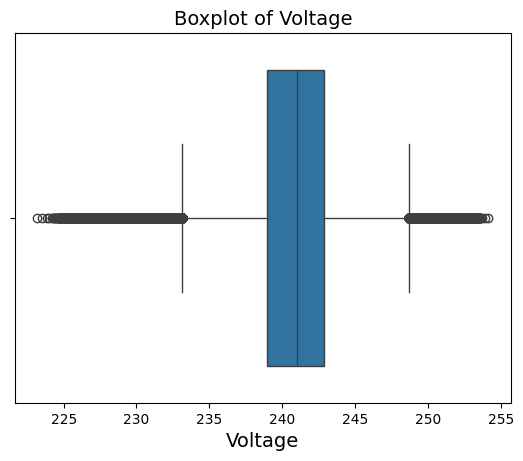

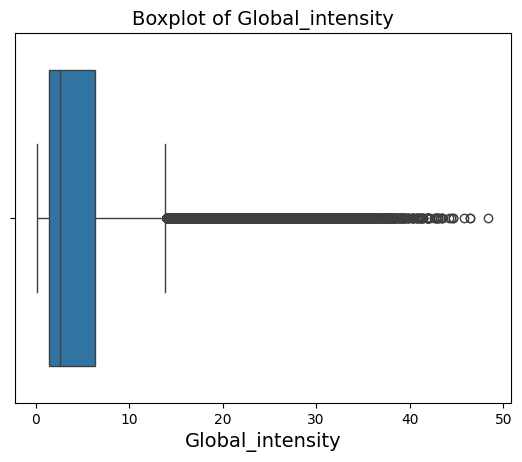

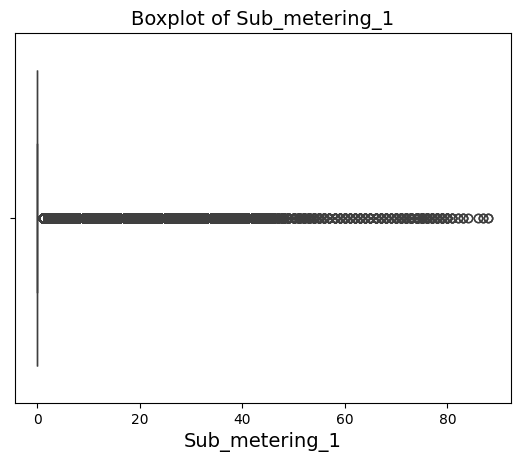

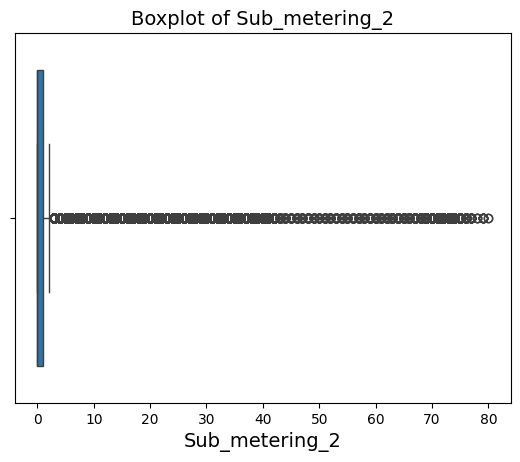

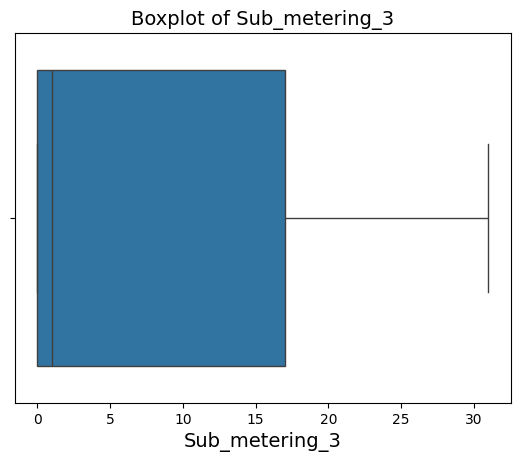

Shape after outlier removal: (1718549, 9)


In [138]:
cat_col2 = [col for col in data2.columns if data2[col].dtype == 'string']#categorical columns string type
num_col2= [col for col in data2.columns if data2[col].dtype == 'float' ]#numerical columns float type

# Print column types
print('Categorical columns:', cat_col2)
print('Numerical columns:', num_col2)


print("Shape before outlier removal:", data2.shape)# print dataset size before removing outliers


for col in num_col2:# Plot boxplots to visually detect outliers
    sns.boxplot(x=data2[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


for col in num_col2:# Remove outliers using the IQR method
    Q1 = data2[col].quantile(0.25)# Calculate quartiles
    Q3 = data2[col].quantile(0.75)
    IQR = Q3 - Q1 # Calculate IQR
    lower = Q1 - 1.5 * IQR# lower limits
    upper = Q3 + 1.5 * IQR# upper limits
    data2 = data2[(data2[col] >= lower) & (data2[col] <= upper)]# Filter the dataset to remove outliers

print("Shape after outlier removal:", data2.shape)# print dataset size after removing outliers

Categorical: ['Date', 'Time']
Numerical: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Shape before outlier removal: (1048575, 9)


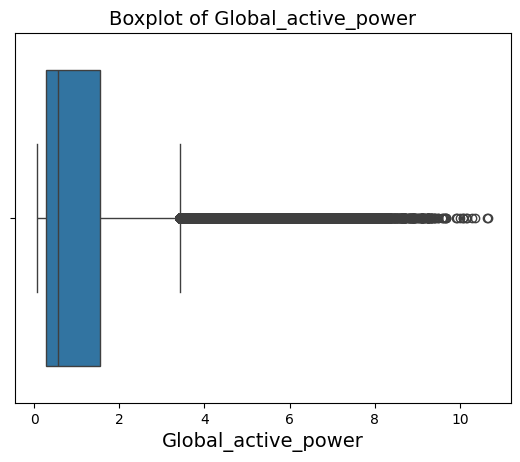

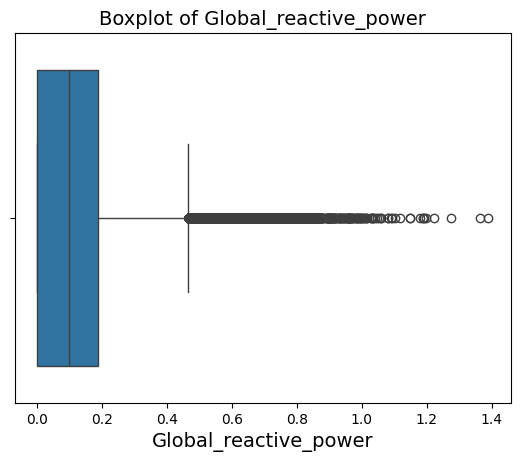

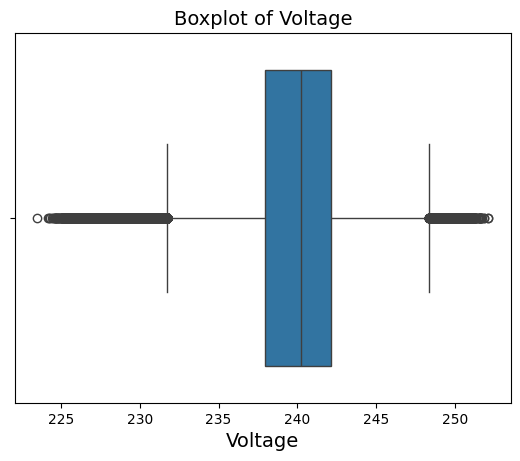

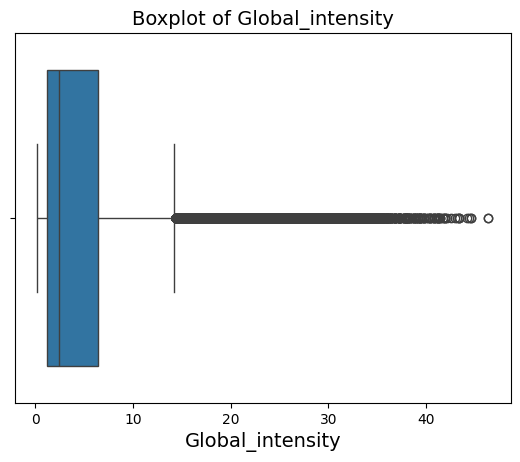

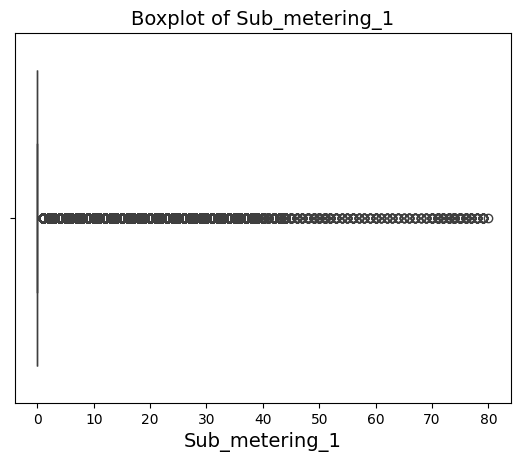

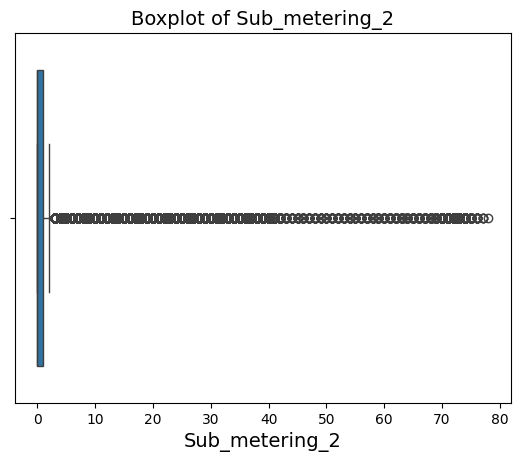

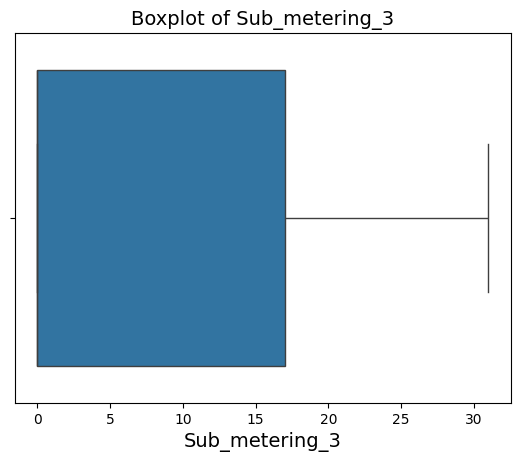

Shape after outlier removal: (884096, 9)


In [139]:
cat_col3 = [col for col in data3.columns if data3[col].dtype == 'string']#categorical columns string type
num_col3 = [col for col in data3.columns if data3[col].dtype == 'float' ]#numerical columns float type
# Print column types
print("Categorical:", cat_col3)
print("Numerical:", num_col3)

print("Shape before outlier removal:", data3.shape)# print dataset size before removing outliers


for col in num_col3:# Plot boxplots to visually detect outliers
    sns.boxplot(x=data3[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


for col in num_col3:# Remove outliers using the IQR method
    Q1 = data3[col].quantile(0.25)# Calculate quartiles
    Q3 = data3[col].quantile(0.75)
    IQR = Q3 - Q1 # Calculate IQR
    lower = Q1 - 1.5 * IQR# lower limits
    upper = Q3 + 1.5 * IQR# upper limits
    data3 = data3[(data3[col] >= lower) & (data3[col] <= upper)]# Filter the dataset to remove outliers

print("Shape after outlier removal:", data3.shape)# print dataset size after removing outliers

## 8. Exploratory Data Visulization

This section includes visual data of all three datasets for better understaning and recognition of whats going on in the datasets.

### Data Visualization

For better understanding of numeric numerical variables, histograms and density plots are created.

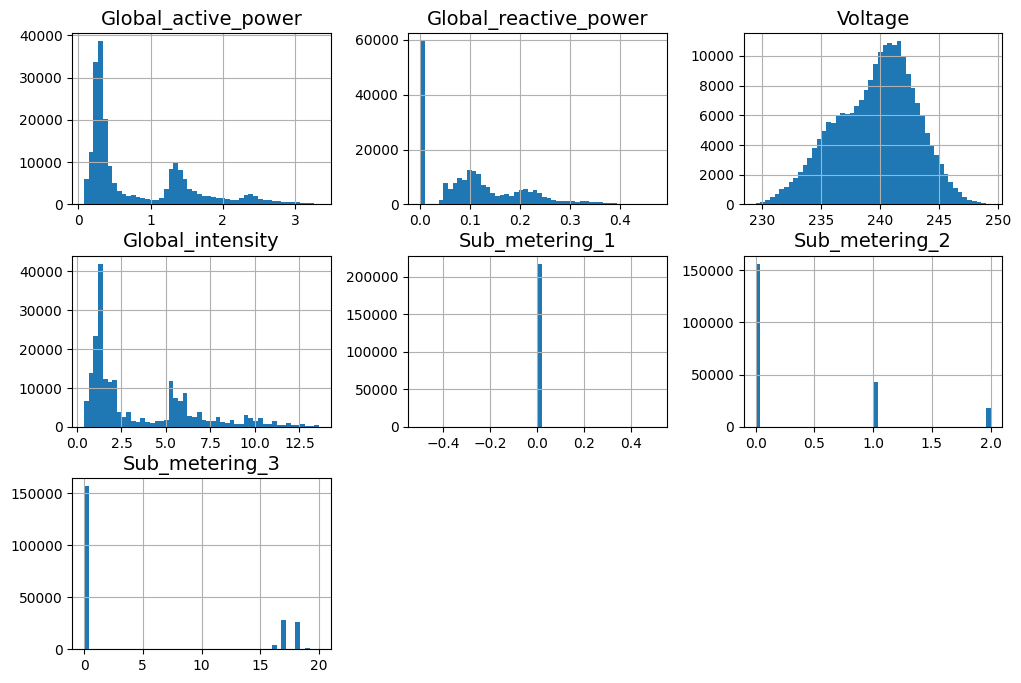

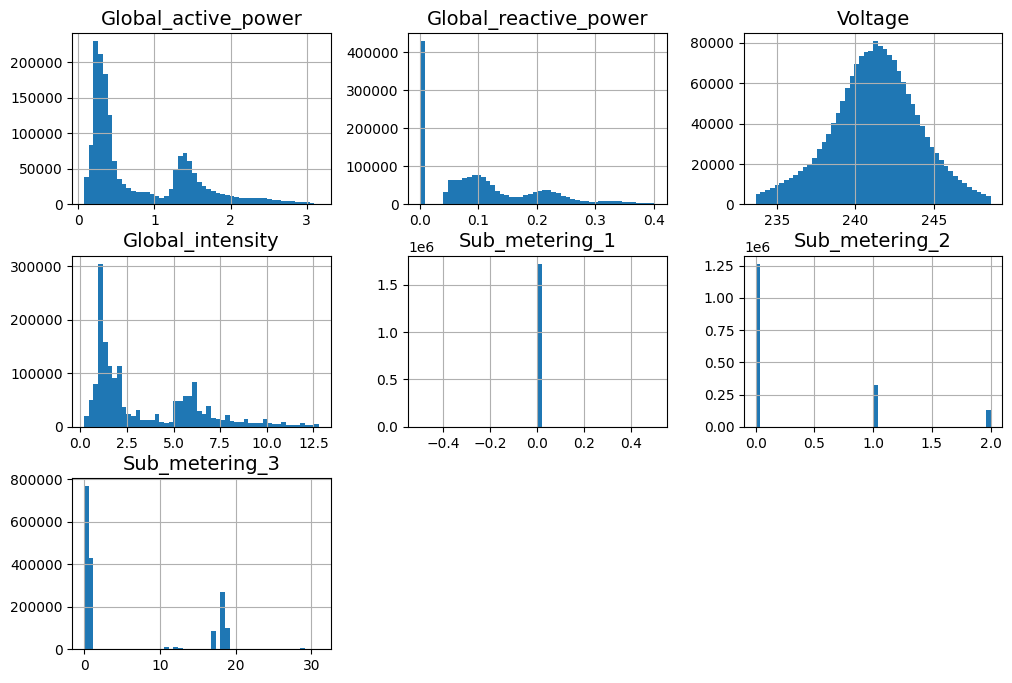

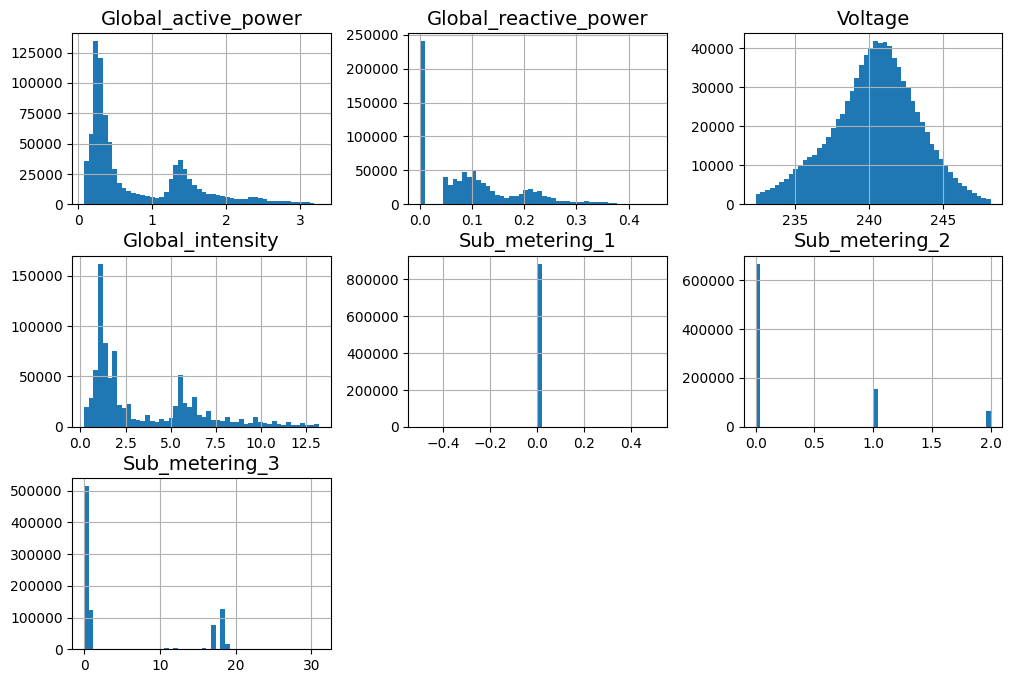

In [140]:
# Set plot style and font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
# Plot histograms for each dataset
data1.hist(bins=50, figsize=(12, 8))
data2.hist(bins=50, figsize=(12, 8))
data3.hist(bins=50, figsize=(12, 8))

plt.show()#displays 

## Intepretation for histograms
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low.

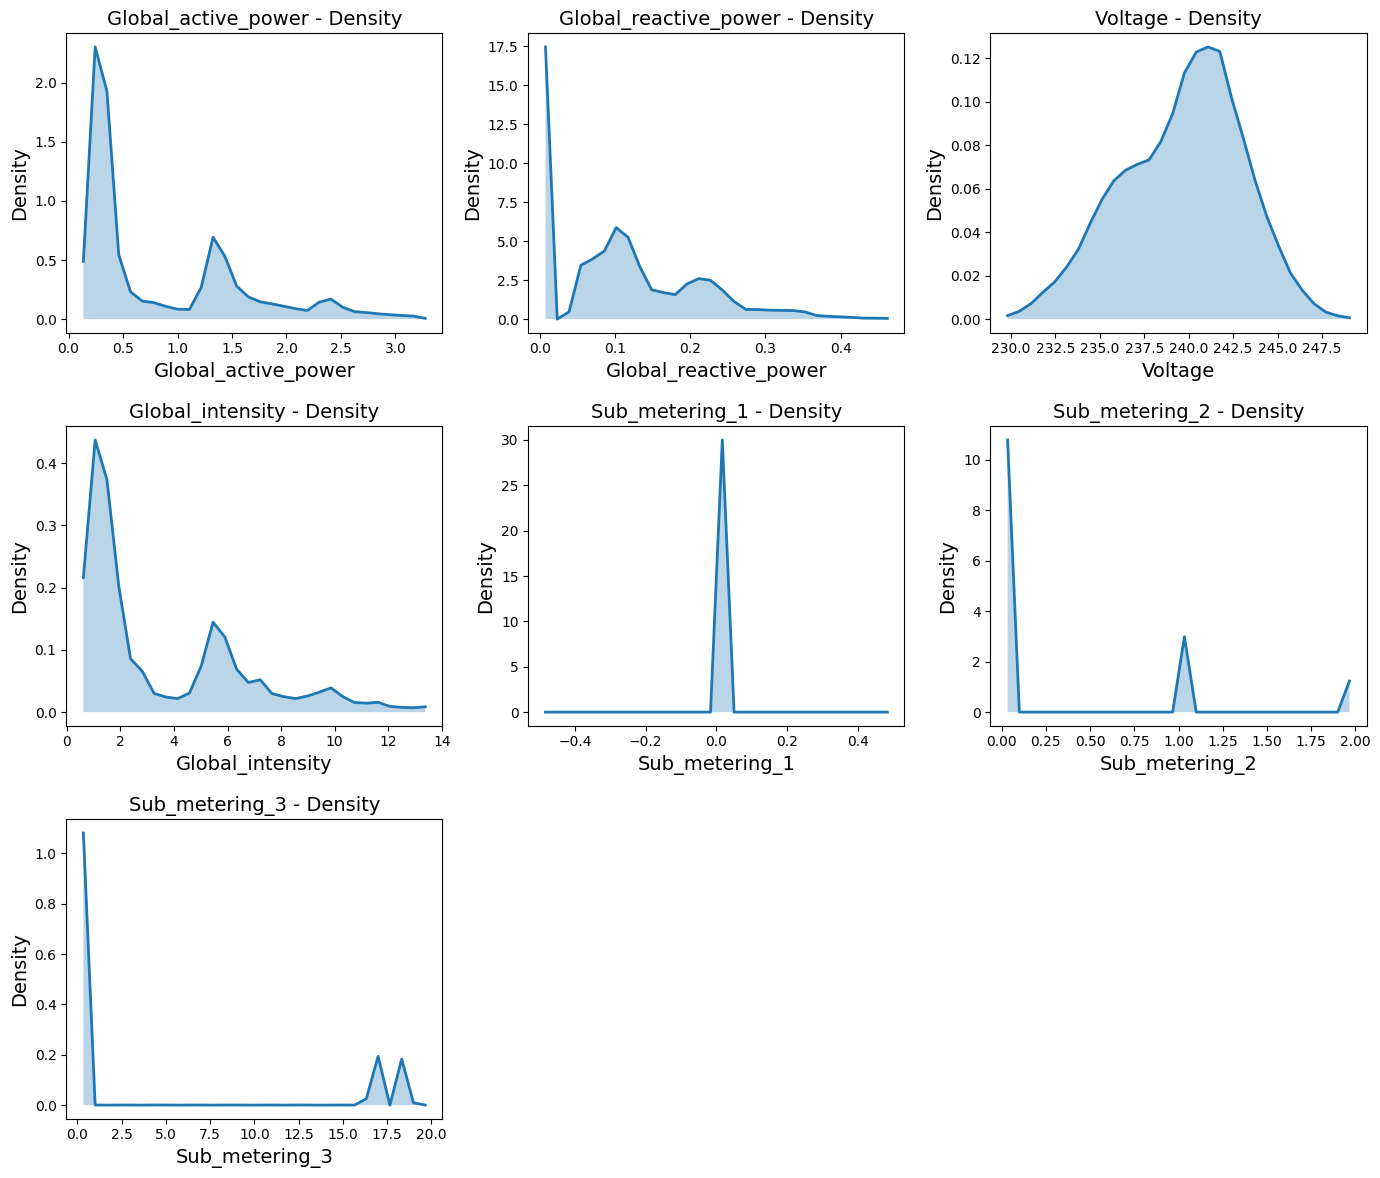

In [141]:
plt.figure(figsize=(14, 12))# Create a large figure to display multiple density plots

# Loop through numerical columns
for i, fname in enumerate(num_col1):
    values = data1[fname].values # Extract column values 
    
    counts, bins = np.histogram(values, bins=30, density=True)# Compute histogram values for density estimation
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Compute bin centers

    
    plt.subplot(3, 3, i+1)# Create subplot for each variable
    plt.plot(bin_centers, counts, linewidth=2)# Plot density curve
    plt.fill_between(bin_centers, counts, alpha=0.3)# Fill area under the curve
    plt.title(f"{fname} - Density")# Set plot labels
    plt.xlabel(fname)
    plt.ylabel("Density")

plt.tight_layout()# Adjust subplot layout
plt.show()# Display plots

### Density Plot Interpretation
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.


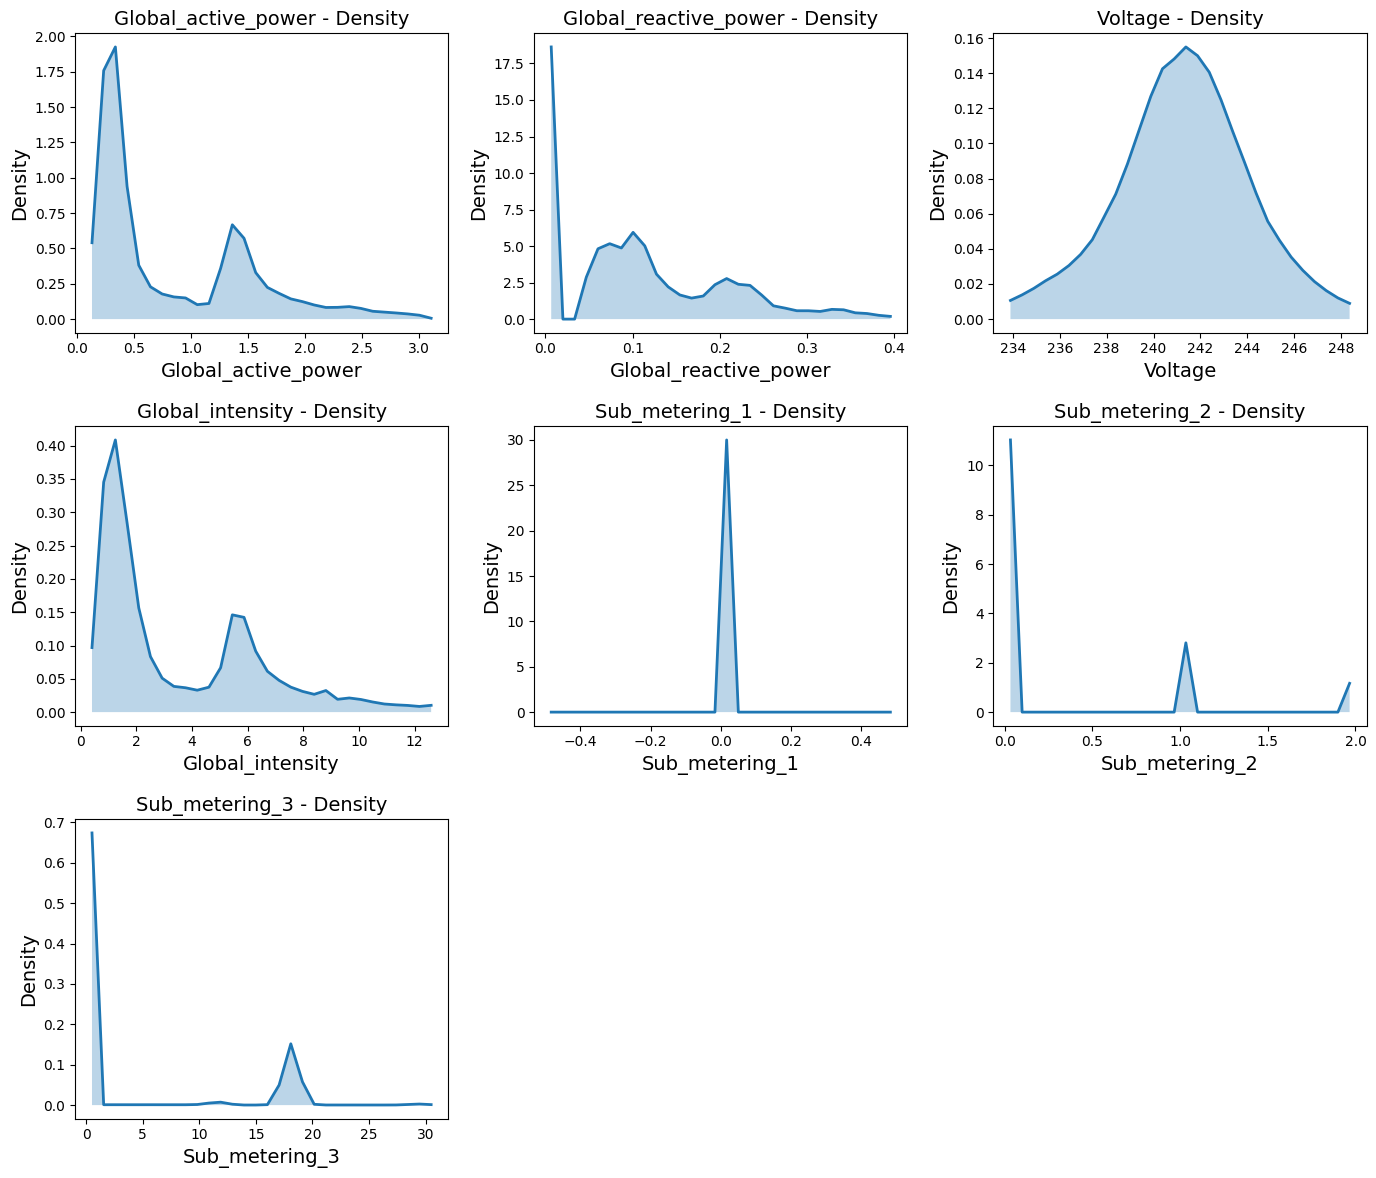

In [142]:
plt.figure(figsize=(14, 12))# Create a large figure to display multiple density plots

# Loop through numerical columns
for i, fname in enumerate(num_col2):
    values = data2[fname].values  # Extract column values 
    
    counts, bins = np.histogram(values, bins=30, density=True)# Compute histogram values for density estimation
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Compute bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot for each variable
    plt.plot(bin_centers, counts, linewidth=2)# Plot density curve
    plt.fill_between(bin_centers, counts, alpha=0.3)# Fill area under the curve
    plt.title(f"{fname} - Density")# Set plot labels
    plt.xlabel(fname)
    plt.ylabel("Density")

plt.tight_layout()# Adjust subplot layout
plt.show()# Display plots

### Density Plot Interpretation Dataset 2
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

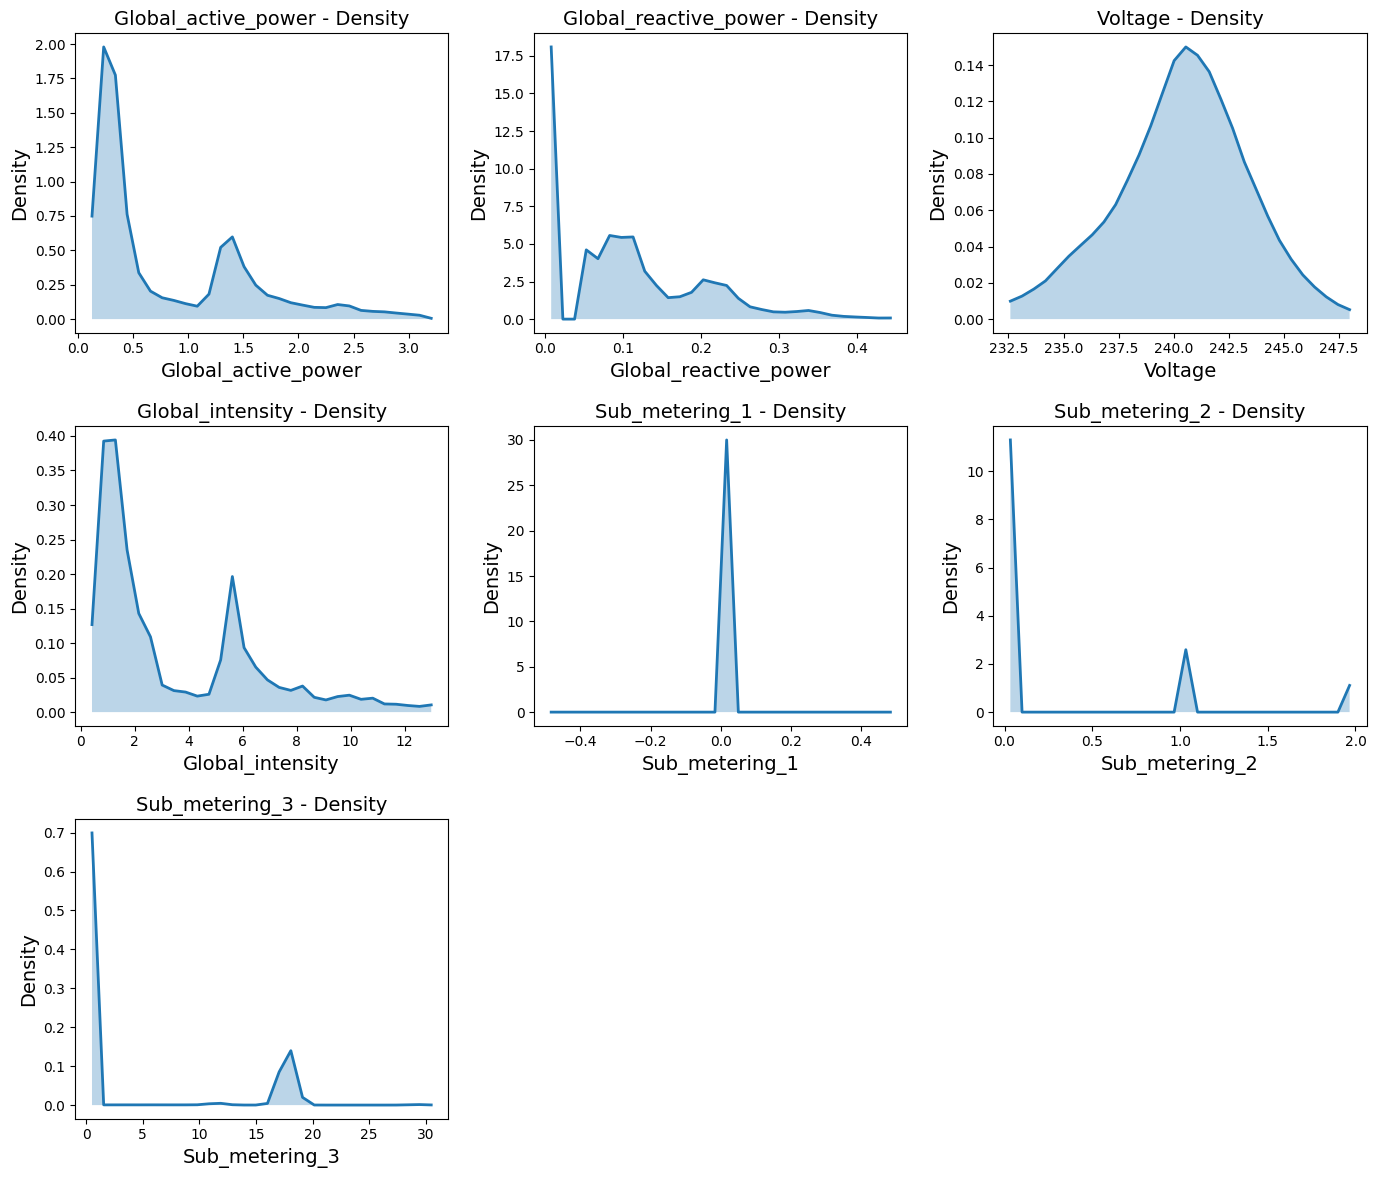

In [143]:
plt.figure(figsize=(14, 12))# Create a large figure to display multiple density plots
# Loop through numerical columns
for i, fname in enumerate(num_col3):
    values = data3[fname].values  # Extract column values 
    
    counts, bins = np.histogram(values, bins=30, density=True)# Compute histogram values for density estimation
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Compute bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot for each variable
    plt.plot(bin_centers, counts, linewidth=2)# Plot density curve
    plt.fill_between(bin_centers, counts, alpha=0.3)# Fill area under the curve
    plt.title(f"{fname} - Density")# Set plot labels
    plt.xlabel(fname)
    plt.ylabel("Density")

plt.tight_layout()# Adjust subplot layout
plt.show()# Display plots

### Density Plot Interpretation Dataset 3
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

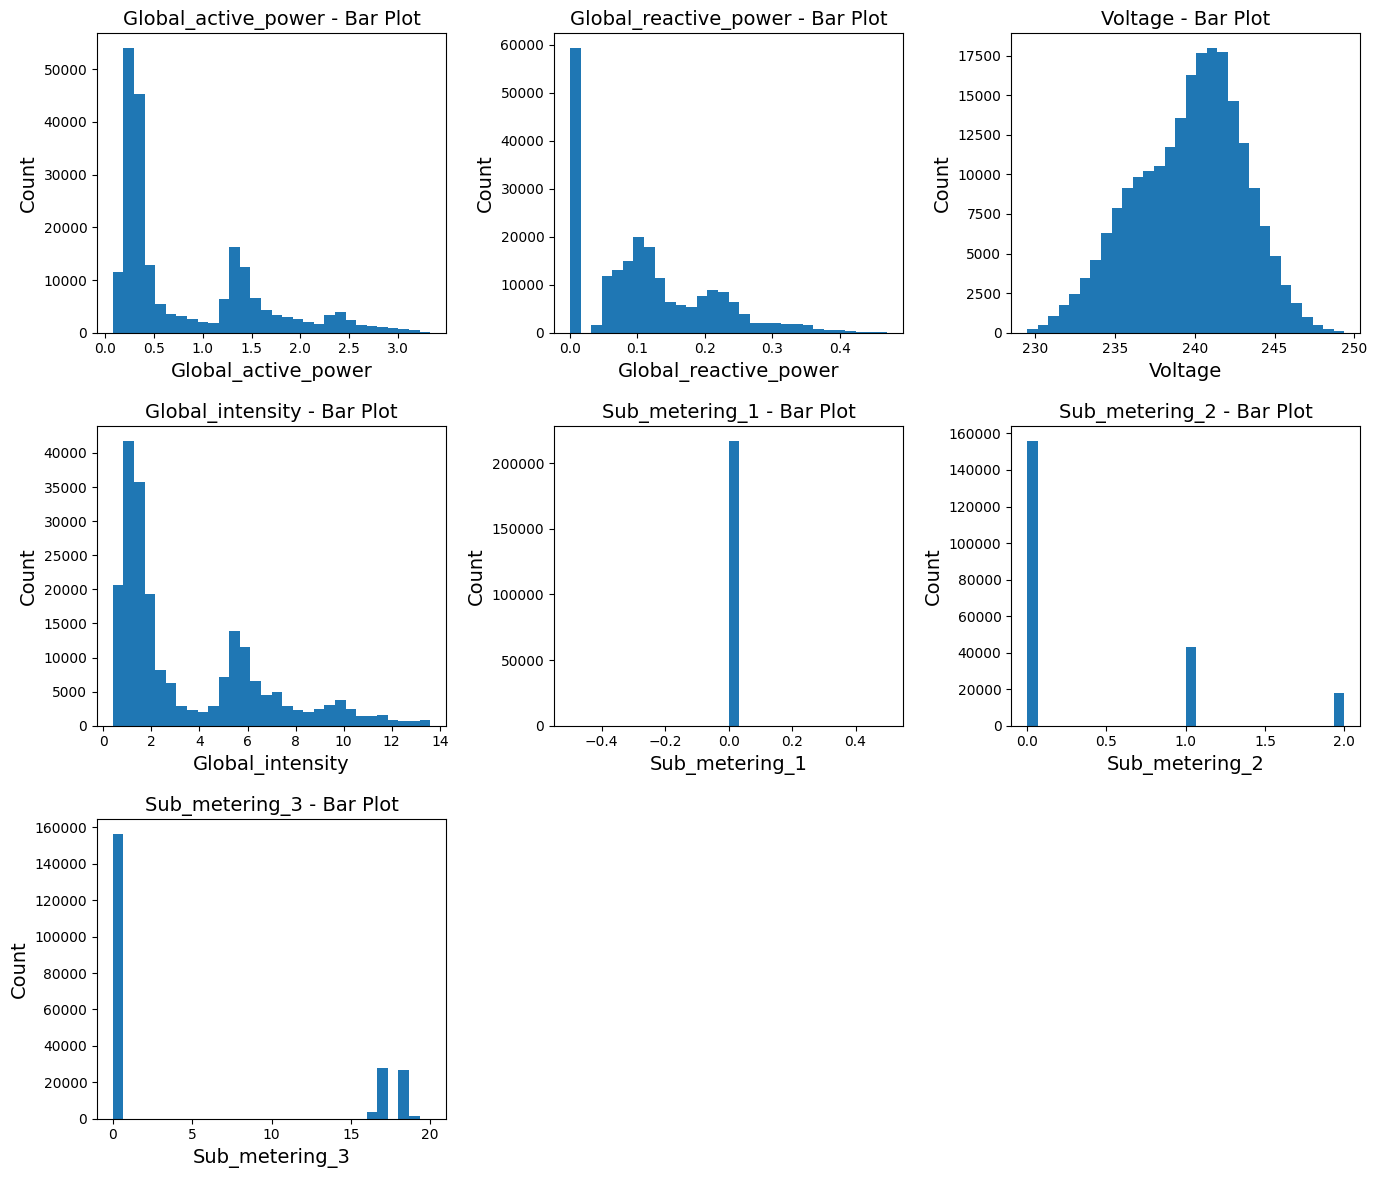

In [144]:
plt.figure(figsize=(14, 12))# Create figure for histogram bar plots

for i, fname in enumerate(num_col1):# Loop through numerical columns in dataset 1
    values = data1[fname].values# Extract values
    
    counts, bins = np.histogram(values, bins=30)# Compute histogram counts and bins
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Calculate bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot
    plt.bar(bin_centers, counts, width=(bins[1] - bins[0]))# Plot histogram as bar chart
    plt.title(f"{fname} - Bar Plot")# Set labels
    plt.xlabel(fname)
    plt.ylabel("Count")

plt.tight_layout()# Adjust layout
plt.show()# Display plots

### Bar Plot Interpretation 
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

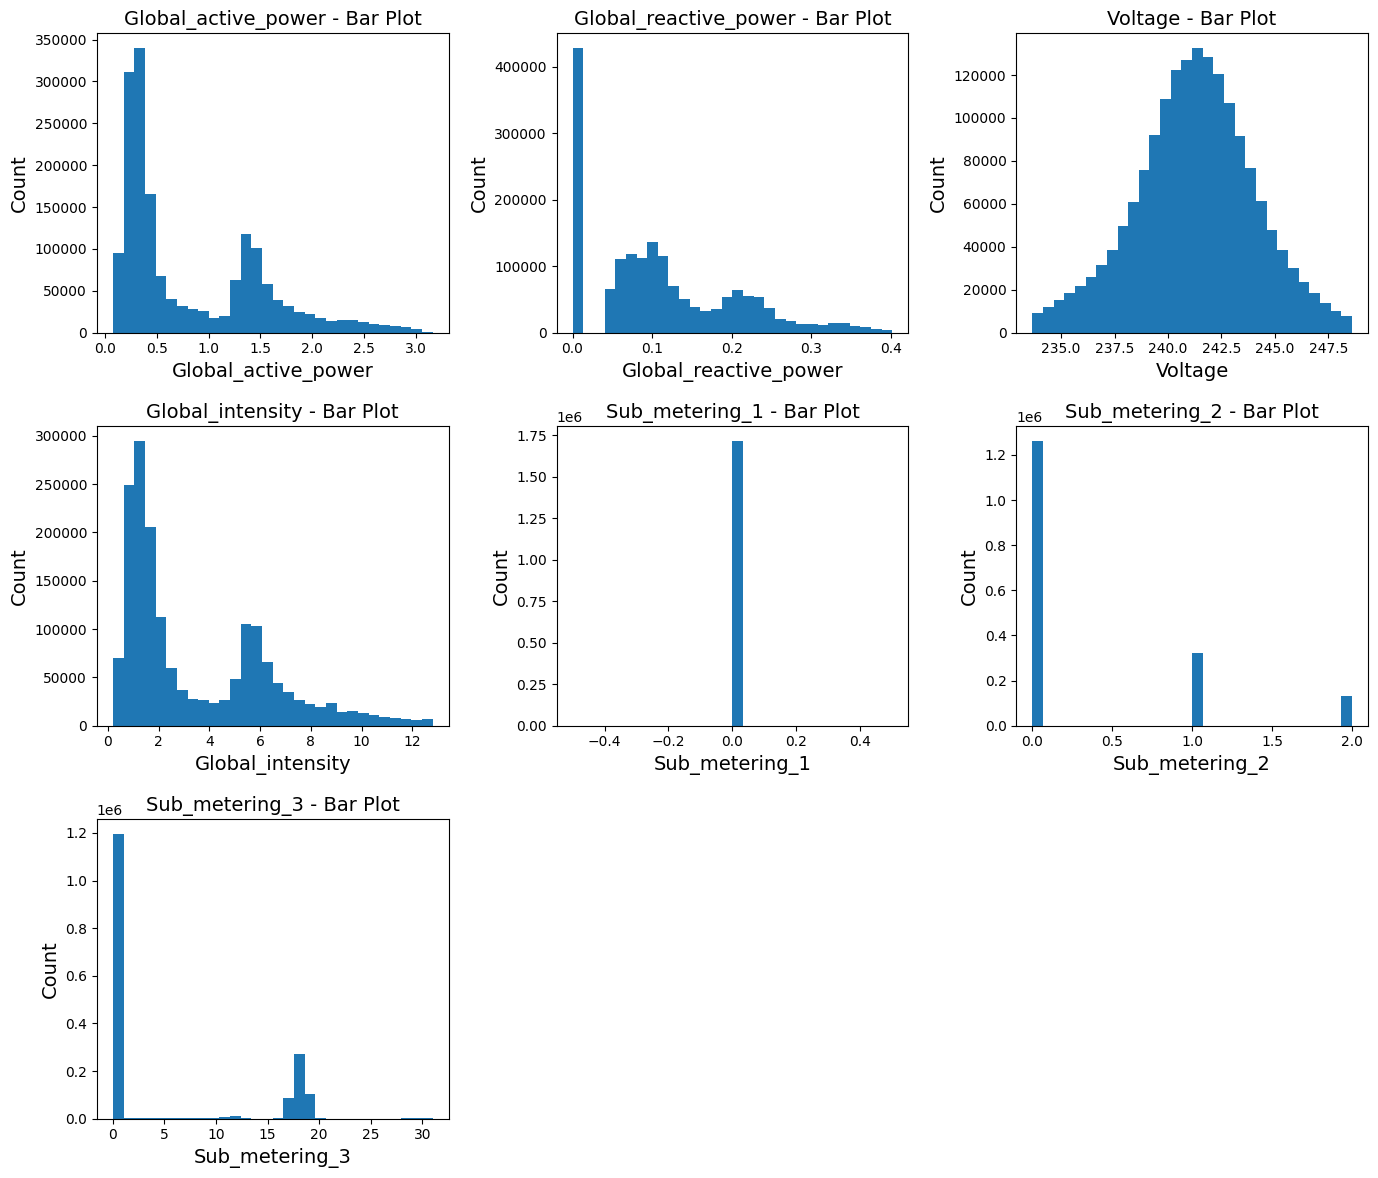

In [145]:
plt.figure(figsize=(14, 12))# Create figure for histogram bar plots

for i, fname in enumerate(num_col2):# Loop through numerical columns in dataset 2
    values = data2[fname].values# Extract values
    
    counts, bins = np.histogram(values, bins=30)# Compute histogram counts and bins
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Calculate bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot
    plt.bar(bin_centers, counts, width=(bins[1] - bins[0]))# Plot histogram as bar chart
    plt.title(f"{fname} - Bar Plot")# Set labels
    plt.xlabel(fname)
    plt.ylabel("Count")

plt.tight_layout()# Adjust layout
plt.show()# Display plots

### Bar Plot Interpretation data set2
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

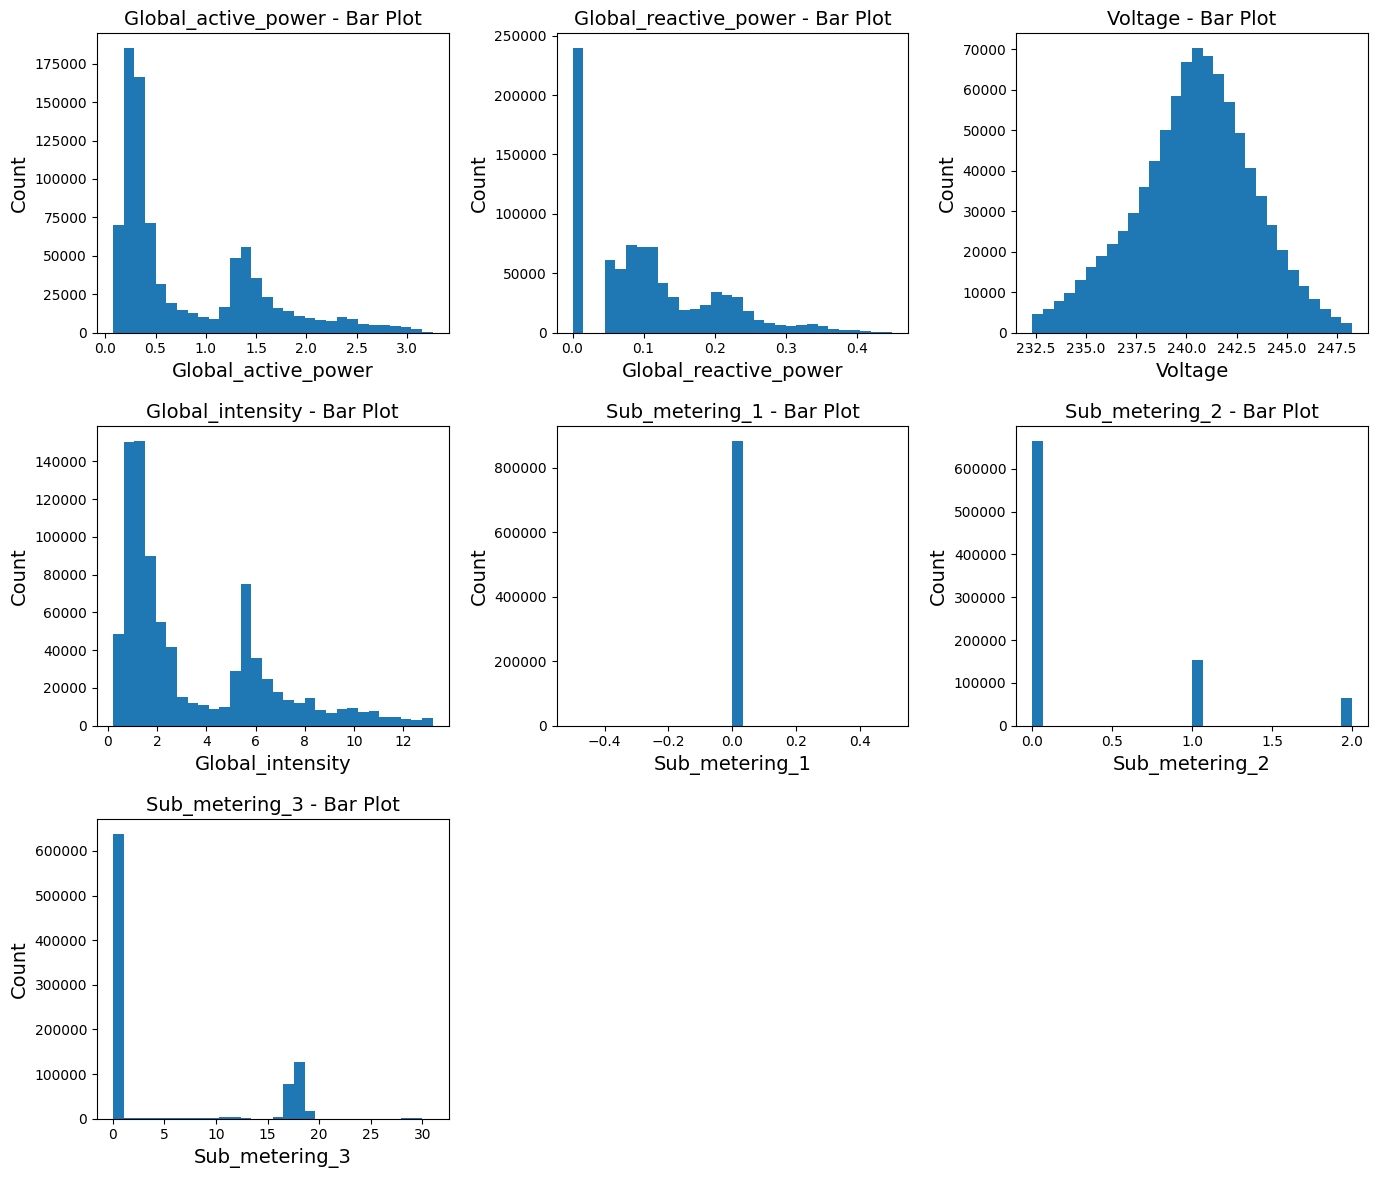

In [146]:
plt.figure(figsize=(14, 12))# Create figure for histogram bar plots

for i, fname in enumerate(num_col3):# Loop through numerical columns in dataset 2
    values = data3[fname].values# Extract values
    
    counts, bins = np.histogram(values, bins=30)# Compute histogram counts and bins
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Calculate bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot
    plt.bar(bin_centers, counts, width=(bins[1] - bins[0]))# Plot histogram as bar chart
    plt.title(f"{fname} - Bar Plot")# Set labels
    plt.xlabel(fname)
    plt.ylabel("Count")

plt.tight_layout()# Adjust layout
plt.show()# Display plots

### Bar Plot Interpretation data set3
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

### 9. Dataset merging
datasets are combined into a single dataset for further analysis and modelling.

In [147]:
merged_data = pd.concat([data1,data2,data3], axis=0, ignore_index=True)# Merge the three datasets into a dataset and reset the index
print(merged_data.head())#display first 5 rows
print("Dataset Shape: ", merged_data.shape)#display the shape of the merged dataset

         Date     Time  Global_active_power  Global_reactive_power  Voltage  \
0  01/01/2007  0:00:00                2.580                  0.136   241.97   
1  01/01/2007  0:01:00                2.552                  0.100   241.75   
2  01/01/2007  0:02:00                2.550                  0.100   241.64   
3  01/01/2007  0:03:00                2.550                  0.100   241.71   
4  01/01/2007  0:04:00                2.554                  0.100   241.98   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              10.6             0.0             0.0             0.0  
1              10.4             0.0             0.0             0.0  
2              10.4             0.0             0.0             0.0  
3              10.4             0.0             0.0             0.0  
4              10.4             0.0             0.0             0.0  
Dataset Shape:  (2819794, 9)


In [148]:
full_data = merged_data.drop_duplicates()# Remove duplicate
print(full_data.shape)#Print shape after removing duplicates

(2526762, 9)


In [149]:
full_data.isna().sum()#number of missing values after merge

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [150]:
# Fill replace missing values in numerical columns using the median
full_data['Global_active_power'].fillna(full_data['Global_active_power'].median(), inplace=True)
full_data['Global_reactive_power'].fillna(full_data['Global_reactive_power'].median(), inplace=True)
full_data['Voltage'].fillna(full_data['Voltage'].median(), inplace=True)
full_data['Global_intensity'].fillna(full_data['Global_intensity'].median(), inplace=True)
full_data['Sub_metering_1'].fillna(full_data['Sub_metering_1'].median(), inplace=True)
full_data['Sub_metering_2'].fillna(full_data['Sub_metering_2'].median(), inplace=True)
full_data['Sub_metering_3'].fillna(full_data['Sub_metering_3'].median(), inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_3244\1360209962.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  full_data['Global_active_power'].fillna(full_data['Global_active_power'].median(), inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_3244\1360209962.py:3: ChainedAssignmentError: A value is being set on a copy of a Da

0           0.0
1           0.0
2           0.0
3           0.0
4           0.0
           ... 
2819540     0.0
2819693    18.0
2819695    17.0
2819696    18.0
2819697    17.0
Name: Sub_metering_3, Length: 2526762, dtype: float64

In [151]:
full_data.info()# Display dataset information

<class 'pandas.DataFrame'>
Index: 2526762 entries, 0 to 2819697
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 192.8 MB


## More Data Cleaning/Preprocessing

In [152]:
full_data["DateTime"] = pd.to_datetime(full_data["Date"].astype(str) + " " + full_data["Time"].astype(str), dayfirst=True, errors="coerce")
full_data = full_data.set_index("DateTime").sort_index()
full_data = full_data.drop(columns=["Date", "Time"])
full_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:54:00,2.720,0.000,235.06,11.6,0.0,0.0,17.0
2006-12-16 17:59:00,2.472,0.058,236.94,10.4,0.0,0.0,17.0
2006-12-16 18:00:00,2.790,0.180,237.52,11.8,0.0,0.0,18.0
2006-12-16 18:01:00,2.624,0.144,238.20,11.0,0.0,0.0,17.0
2006-12-16 18:02:00,2.772,0.118,238.28,11.6,0.0,0.0,17.0


In [153]:
full_data = full_data.drop_duplicates()# Remove duplicates

## 10. Correlation Analysis & Feature Selection

We a correlation heatmap for our final merged dataset to check for weak variables, correlated features that are high, and any columns that should be removed before our models are created.

In [154]:
cat_col_full = [col for col in full_data.columns if full_data[col].dtype == 'string']#categorical columns string type
num_col_full= [col for col in full_data.columns if full_data[col].dtype == 'float' ]#numerical columns float type

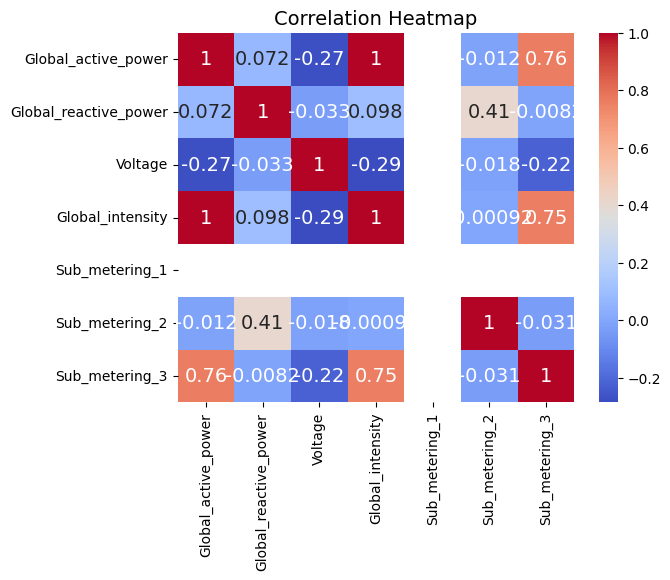

In [155]:
corr = full_data[num_col_full].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Correlation Analysis Results

Looking at the heatmap, Sub_metering_1 showed no meaningful correlation 
with any other feature in the dataset, appearing completely blank across 
its row and column. Since it contributes no useful signal for predicting 
Global_active_power, it was dropped before model training to keep the 
feature set clean.

In [156]:
full_data = full_data.drop(columns=["Sub_metering_1"])

## 11. Identifying The Target Variable & Splitting Training, Testing, and Validation

Our target variable as mentioned at the strat of our project is `Global_active_power`, while the rest of our features are the input variables. After that the dataset is split into training, validation, and testing sets.

In [157]:
y = full_data["Global_active_power"].astype(float)
X = full_data.drop(columns=["Global_active_power"])

feature_names = X.columns.tolist()

print("Feature shape:", X.shape, "Target shape: ", y.shape)
print("Features:", feature_names)

#splits the data into different sets the test size means that that percentage will be set aside for test data while the random state keeps the model replicable
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Feature shape: (1601774, 5) Target shape:  (1601774,)
Features: ['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_2', 'Sub_metering_3']
Train: (1121241, 5)
Validation: (240266, 5)
Test: (240267, 5)


## 12. Scaling Features

We decided to go for scaling due to how useful it is when used on linear modeels (later used in our project), standardisation is used so the numerical input fetaures are placed on a similar scale before model training.

In [158]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 1121241
Test samples: 240267


## 13. Models

For the three models used. We will be using 3 evaluation metrics: 
1. R²(Coefficient of Determination): Shows how well the model explainsthe variations in the data
2. MAE(Mean Absolute Error): Measures the average size of the errors.
3. RMSE(Root Mean Squared Error): Measures how far predictions are from the true values on average, with larger mistakes punished more heavily because the errors are squared before averaging.

## Linear Regression

We chose Linear Regression as a baseline model. Before throwing more complex 
models at the data, it is good practice to establish a simple reference point 
to measure everything else against. If a more complex model cannot beat a 
straight line, then that is likely the wrong model to choose.

In [159]:
linReg = linear_model.LinearRegression()
linReg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## K-Nearest Neighbours (KNN) Regression model

KNN was selected based on findings from our research, which showed it 
performing well on similar energy consumption datasets. Unlike Linear 
Regression, KNN makes no assumptions about the shape of the data and instead 
predicts based on the closest matching examples it has seen, making it a 
reasonable choice for data that may not follow a strictly linear pattern.

In [160]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Random Forest Regression

Random Forest was chosen based on our research similar to KNN, where Decision Trees came up as a strong performing model. Random Forest builds directly on the same concept, using multiple Decision Trees and averaging their results rather than relying on just one. We went with Random Forest over a single Decision Tree since combining multiple trees reduces overfitting and generally produces more reliable predictions especially for larger datasets such as ours.

In [161]:
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

## 14. Model Evaluation

With all three models trained, we now evaluate their performance using both the validation and test sets. Each model is scored across the three metrics we chose. 

In [162]:
y_val_lin = linReg.predict(X_val_scaled)
y_test_lin = linReg.predict(X_test_scaled)


val_r2_lin = r2_score(y_val, y_val_lin)
test_r2_lin = r2_score(y_test, y_test_lin)

val_rmse_lin = np.sqrt(mean_squared_error(y_val, y_val_lin))
test_rmse_lin = np.sqrt(mean_squared_error(y_test, y_test_lin))


val_mae_lin = mean_absolute_error(y_val, y_val_lin)
test_mae_lin = mean_absolute_error(y_test, y_test_lin)

print("Linear Regression")
print("Validation: R² =", val_r2_lin, "RMSE =", val_rmse_lin, "MAE =", val_mae_lin)
print("Test:       R² =", test_r2_lin, "RMSE =", test_rmse_lin, "MAE =", test_mae_lin)

y_val_knn = knn.predict(X_val_scaled)
y_test_knn = knn.predict(X_test_scaled)

val_r2_knn = r2_score(y_val, y_val_knn)
test_r2_knn = r2_score(y_test, y_test_knn)

val_rmse_knn = np.sqrt(mean_squared_error(y_val, y_val_knn))
test_rmse_knn = np.sqrt(mean_squared_error(y_test, y_test_knn))

val_mae_knn = mean_absolute_error(y_val, y_val_knn)
test_mae_knn = mean_absolute_error(y_test, y_test_knn)

print("KNN Regressor")
print("Validation: R² =", val_r2_knn, "RMSE =", val_rmse_knn, "MAE =", val_mae_knn)
print("Test:       R² =", test_r2_knn, "RMSE =", test_rmse_knn, "MAE =", test_mae_knn)


y_val_rf = rf.predict(X_val_scaled)
y_test_rf = rf.predict(X_test_scaled)

val_r2_rf = r2_score(y_val, y_val_rf)
test_r2_rf = r2_score(y_test, y_test_rf)

val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_rf))

val_mae_rf = mean_absolute_error(y_val, y_val_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_rf)

print("Random Forest Regressor")
print("Validation: R² =", val_r2_rf, "RMSE =", val_rmse_rf, "MAE =", val_mae_rf)
print("Test:       R² =", test_r2_rf, "RMSE =", test_rmse_rf, "MAE =", test_mae_rf)

Linear Regression
Validation: R² = 0.9976103863454104 RMSE = 0.03435597141306896 MAE = 0.02239356956297457
Test:       R² = 0.9976745602676789 RMSE = 0.03391954582247508 MAE = 0.022312420246722003
KNN Regressor
Validation: R² = 0.9976997826949581 RMSE = 0.03370721105117064 MAE = 0.019968251854194936
Test:       R² = 0.9977427509297431 RMSE = 0.03341852101349286 MAE = 0.019943875771537497
Random Forest Regressor
Validation: R² = 0.997934538449013 RMSE = 0.03194088495481536 MAE = 0.018337596302621634
Test:       R² = 0.9980035433094946 RMSE = 0.03142877334173016 MAE = 0.01824978715249964


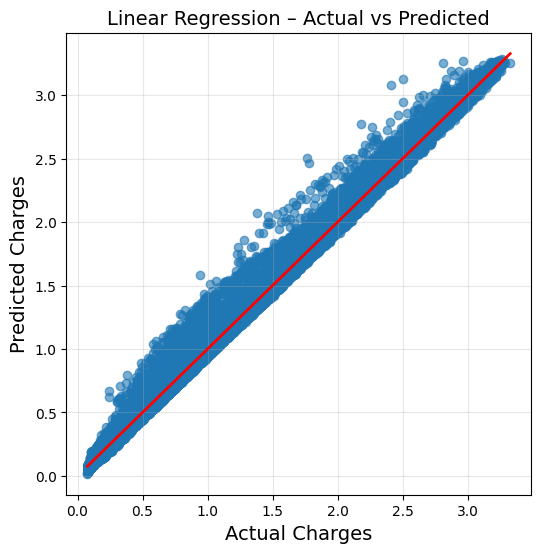

In [163]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_lin, alpha=0.6)
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, color="red", linewidth=2)
plt.title("Linear Regression – Actual vs Predicted")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.grid(alpha=0.3)
plt.show()

The scatterplot above dispalys the actual vs predicted values. The model is making accurate predictions based on the fact that most of the points are very close to the diagonal line. But, this is mainly because global_intensity have similar roles to the target variable which is global_active_power. Meaning, the Linear Regression Model above is using a feature that already gives it a strong hint about the answer.

In conclusion, it may look like the results are very good, but actually the model is not actually learning from all the data, it is really relying heavily on one feature. This can look decieving to the eye but it is not.

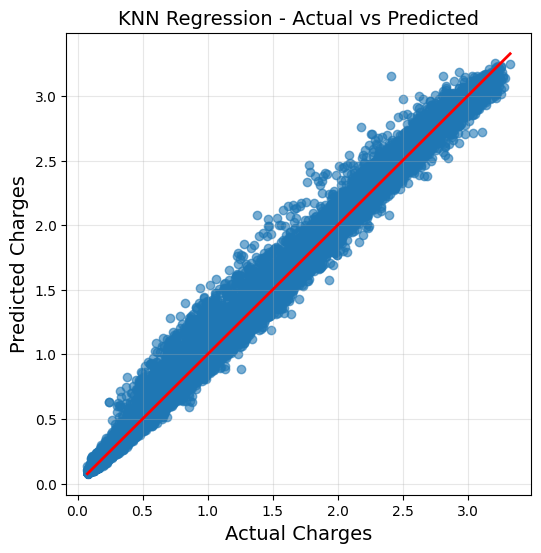

In [164]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_knn, alpha=0.6)
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, color="red", linewidth=2)
plt.title("KNN Regression - Actual vs Predicted")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.grid(alpha=0.3)
plt.show()

The graph shows mild undrifting, predictions are leveled hence there inst sharp variations in the data . The points spread widely around the diagonal instead of following it . In conclusion , This means knn isnt showing the relationship porperly and is averaging .

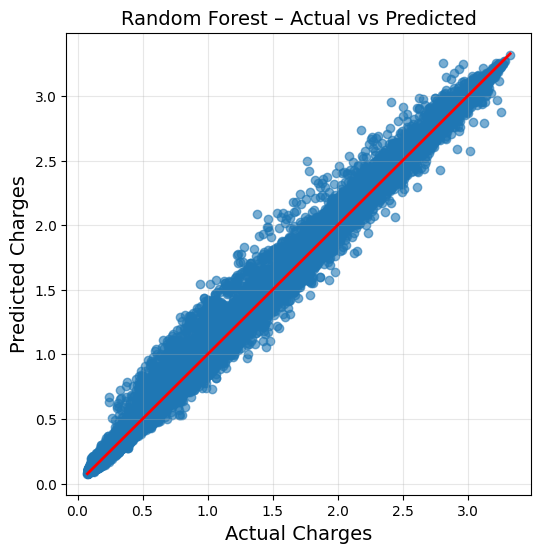

In [165]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_rf, alpha=0.6)
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, color="red", linewidth=2)
plt.title("Random Forest – Actual vs Predicted")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.grid(alpha=0.3)
plt.show()

The Random Forest model achieves pretty impressive scores on both validation and test sets. Meaning that the model explains the variance in the data pretty well and produces predictions that are very close to the actual values without overfitting. The scatter plot confirms this, with points tightly gathered along the diagonal across the full range of consumption values.

## Validation

To back up the initial evaluation results, two cross-validation methods were used: K-Fold and ShuffleSplit. 

K-Fold splits the data into 5 equal folds and rotates through them so every sample gets tested exactly once. ShuffleSplit runs 10 independent random splits, each time grabbing 20% of the data for testing with no overlap rules. 

The two methods approach the same problem differently, so if both come back with consistent results, that is stronger evidence than either one alone.

## 15. K-Cross Validation

In [166]:
# Define KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("Cross Validation Results\n------------------------")

# Linear Regression
lr_cv = cross_val_score(linReg, X_train_scaled, y_train, cv=kfold, scoring='r2')
print("Linear Regression:")
print("R² Mean:", lr_cv.mean())
print("Std Dev:", lr_cv.std())
print()

# KNN
knn_cv = cross_val_score(knn, X_train_scaled, y_train, cv=kfold, scoring='r2')
print("KNN Regressor:")
print("R² Mean:", knn_cv.mean())
print("Std Dev:", knn_cv.std())
print()

# Random Forest
rf_cv = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='r2')
print("Random Forest:")
print("R² Mean:", rf_cv.mean())
print("Std Dev:", rf_cv.std())

Cross Validation Results
------------------------
Linear Regression:
R² Mean: 0.9976539469638507
Std Dev: 3.4841346877470426e-05

KNN Regressor:
R² Mean: 0.9976689762786719
Std Dev: 2.7171172535948715e-05

Random Forest:
R² Mean: 0.9979659401961257
Std Dev: 2.125465044976056e-05


## 16. Evalution Metric Comparison

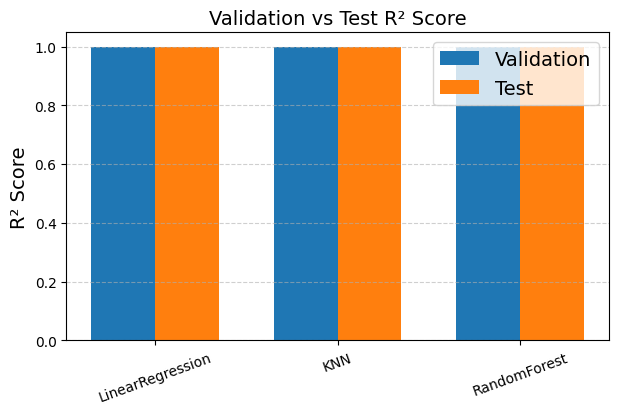

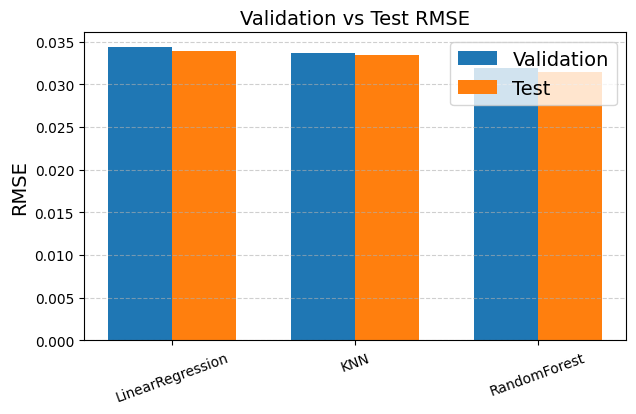

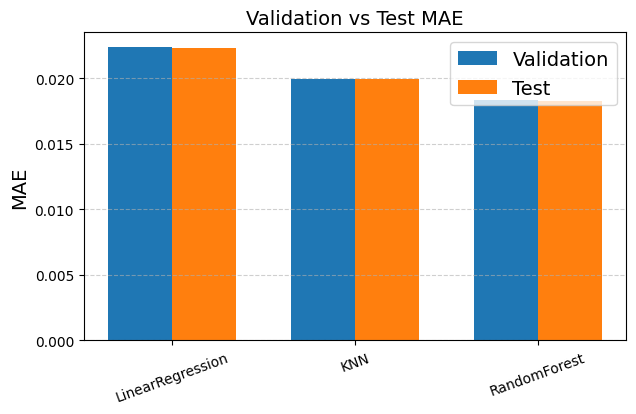

In [167]:
# List of name of models 
models = ["LinearRegression", "KNN", "RandomForest"]

# Validation metrics for each model.
val_r2 = [val_r2_lin, val_r2_knn, val_r2_rf]
val_rmse = [val_rmse_lin, val_rmse_knn, val_rmse_rf]
val_mae = [val_mae_lin, val_mae_knn, val_mae_rf]

# Test metrics for each model.
test_r2 = [test_r2_lin, test_r2_knn, test_r2_rf]
test_rmse = [test_rmse_lin, test_rmse_knn, test_rmse_rf]
test_mae = [test_mae_lin, test_mae_knn, test_mae_rf]
# list of metrics for both validation and test models.
metrics = [
    ("R² Score", val_r2, test_r2),
    ("RMSE", val_rmse, test_rmse),
    ("MAE", val_mae, test_mae)
]

for metric_name, val_scores, test_scores in metrics:    # Generates bar charts by looping each metric.
    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(7, 4))  # figure size.
    plt.bar(x - width/2, val_scores, width, label="Validation")
    plt.bar(x + width/2, test_scores, width, label="Test")
    plt.xticks(x, models, rotation=20)
    plt.ylabel(metric_name)
    plt.title(f"Validation vs Test {metric_name}")  # Title of chart.
    plt.legend()    # To differentiate bars.
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()  # Outputs the charts.

The bar charts above show us the difference in performance across all three models. We can highlight that the Random Forest Regressor model achieves the highest R² (R-squared) and the lowest RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error) which generally indicates that it is the best model on both validation data and test data.

## 17. ShuffleSplit Validation

In [168]:
#Define ShuffleSplit

ss = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)


# Linear Regression
lr_ss = cross_val_score(linReg, X_train_scaled, y_train, cv=ss, scoring='r2')
print("Linear Regression:")
print("R² Mean:", lr_ss.mean())
print("Std Dev:", lr_ss.std())
print()

# KNN
knn_ss = cross_val_score(knn, X_train_scaled, y_train, cv=ss, scoring='r2')
print("KNN Regressor:")
print("R² Mean:", knn_ss.mean())
print("Std Dev:", knn_ss.std())
print()

# Random Forest
rf_ss = cross_val_score(rf, X_train_scaled, y_train, cv=ss, scoring='r2')
print("Random Forest:")
print("R² Mean:", rf_ss.mean())
print("Std Dev:", rf_ss.std())

Linear Regression:
R² Mean: 0.9976736632472825
Std Dev: 3.762924320365095e-05

KNN Regressor:
R² Mean: 0.9976872484448525
Std Dev: 4.0229916602559855e-05

Random Forest:
R² Mean: 0.9979843272470642
Std Dev: 4.159723152047988e-05


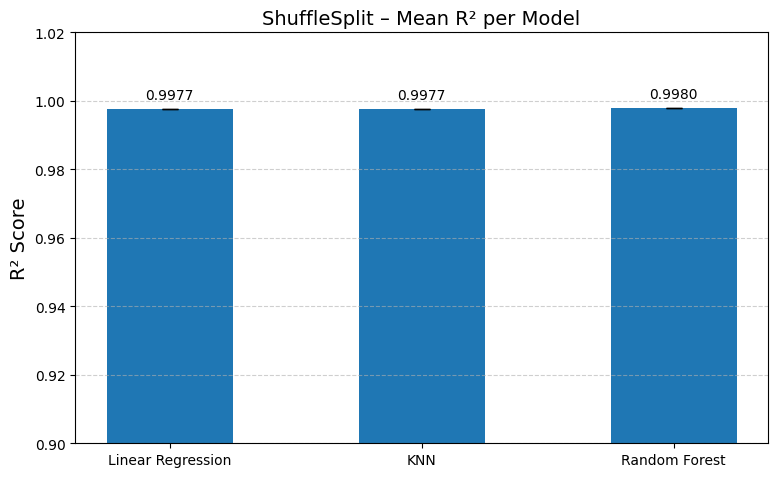

In [ ]:
# ShuffleSplit results for each model
models = ["Linear Regression", "KNN", "Random Forest"]

ss_means = [lr_ss.mean(), knn_ss.mean(), rf_ss.mean()]
ss_stds  = [lr_ss.std(),  knn_ss.std(),  rf_ss.std()]

x = np.arange(len(models))
width = 0.5

plt.figure(figsize=(8, 5))
bars = plt.bar(x, ss_means, width, color=["steelblue", "orange", "green"],yerr=ss_stds, capsize=6) # error bars show std dev

for bar, mean in zip(bars, ss_means):
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.002,f"{mean:.4f}",ha='center', va='bottom', fontsize=10) # add r^2 value labels on top of each bar

plt.xticks(x, models)
plt.ylabel("R² Score")
plt.title("ShuffleSplit Validation - Mean R² per Model")
plt.ylim(0.9, 1.02)  # zoom in since all scores are above 0.99
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Both K-Fold and ShuffleSplit returned r^2 scores of roughly 99.7% across all three models, which at this point is pretty hard to argue with. Random Forest excelled slightly in both tests with the highest mean and the tightest scores, while Linear Regression and KNN were nearly identical throughout. The standard deviations also tell us some important insight. Both K-fold and ShuffleSplit produced standard deviations that were extremely low, meaning across 15 total runs using two completely different validation strategies, the scores barely moved. The high accuracy is not a fluke, it is just what these models consistently do on this data.

## 18. Best Model

In [170]:
# R² scores validation for each model
val_scores = {
    "Linear Regression": val_r2_lin,  
    "KNN Regressor": val_r2_knn,     
    "Random Forest Regressor": val_r2_rf
}


best_model_name = max(val_scores, key=val_scores.get)   # Model name using the higest R²
print("Best model: ", best_model_name)

# This code is for showing the model object to select the modl name. 
best_model = {
    "Linear Regression": linReg,
    "KNN Regressor": knn,
    "Random Forest Regressor": rf
}[best_model_name]

Best model:  Random Forest Regressor


## Best Model: Random Forest Regressor 

Random Forest was chosen as the best model because it has the highest R² score between the models.
It leads to more accurate predictions because it captures more complex patterns and performs better than KNN and Linear Regression.

## 19. Best Model Saved

Finally, we save the best model using joblib in order to be used in the demo. This is the final step of our project.

In [172]:
joblib.dump(best_model, "best_regression_model.joblib") # Using joblib to save the best model selected.
print("Saved best model to best_regression_model.joblib")

joblib.dump(scaler, "scaler.joblib")
print("Saved scaler to scaler.joblib")

Saved best model to best_regression_model.joblib
Saved scaler to scaler.joblib
